In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error


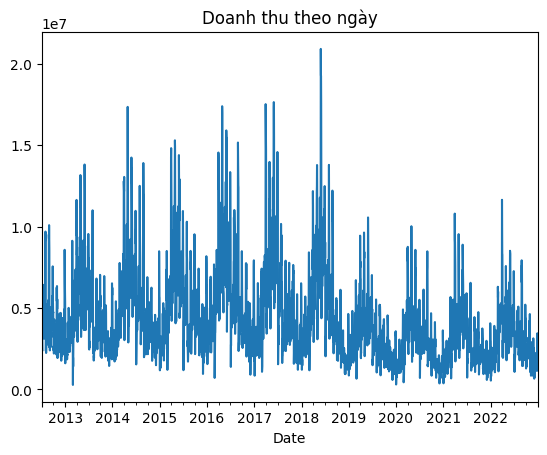

In [60]:
df = pd.read_csv("../../sales.csv", parse_dates=["Date"], index_col="Date")
df = df.asfreq("D")          # đảm bảo tần suất ngày
df["Revenue"].plot(title="Doanh thu theo ngày")
plt.show()


In [61]:
def adf_test(series):
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("→ Chuỗi DỪNG" if result[1] < 0.05 else "→ Cần lấy SAI PHÂN")


In [62]:
adf_test(df["Revenue"])


ADF Statistic: -2.5250
p-value: 0.1095
→ Cần lấy SAI PHÂN


In [63]:
df["Revenue_diff"] = df["Revenue"].diff()
adf_test(df["Revenue_diff"])


ADF Statistic: -23.5321
p-value: 0.0000
→ Chuỗi DỪNG


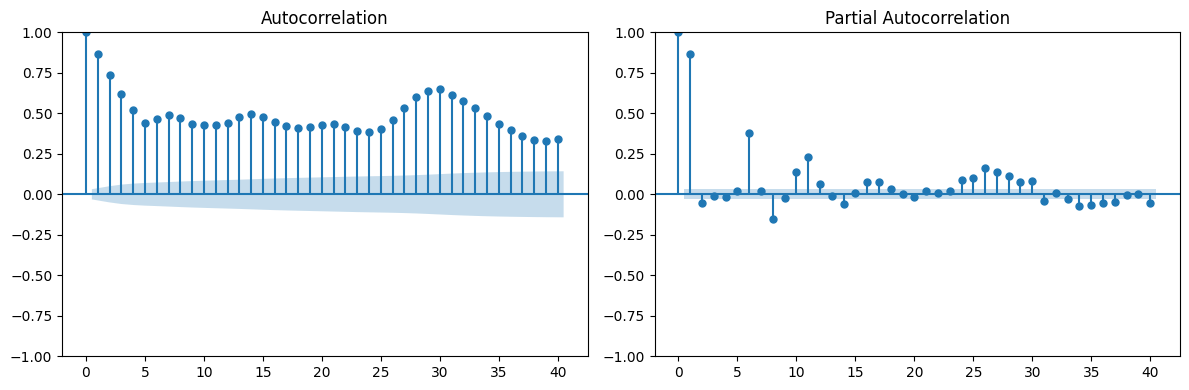

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df["Revenue"].dropna(), lags=40, ax=axes[0])
plot_pacf(df["Revenue"].dropna(), lags=40, ax=axes[1])
plt.tight_layout()
plt.show()


In [65]:
model_auto = auto_arima(
    df["Revenue"],
    seasonal=True,
    m=7,                    # chu kỳ mùa vụ (7=tuần, 365=năm)
    d=None,                 # tự phát hiện d
    D=None,                 # tự phát hiện D
    information_criterion="aic",
    stepwise=True,          # nhanh hơn exhaustive search
    trace=True,             # in kết quả từng bước
    error_action="ignore",
    suppress_warnings=True,
)
print(model_auto.summary())


Performing stepwise search to minimize aic


KeyboardInterrupt: 

In [ ]:
train = df["Revenue"][:-30]   # dùng 30 ngày cuối để test
test  = df["Revenue"][-30:]


In [ ]:
train = df["Revenue"]


In [ ]:
order         = model_auto.order           # (p, d, q)
seasonal_order = model_auto.seasonal_order # (P, D, Q, s)


In [ ]:
model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
result = model.fit(disp=False)
print(result.summary())


                                     SARIMAX Results                                     
Dep. Variable:                           Revenue   No. Observations:                 3833
Model:             SARIMAX(1, 1, 2)x(2, 0, 2, 7)   Log Likelihood              -60529.097
Date:                           Fri, 24 Apr 2026   AIC                         121074.193
Time:                                   16:40:17   BIC                         121124.167
Sample:                               07-04-2012   HQIC                        121091.950
                                    - 12-31-2022                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6376      0.103      6.187      0.000       0.436       0.840
ma.L1         -2.4283      0.092    -26.518

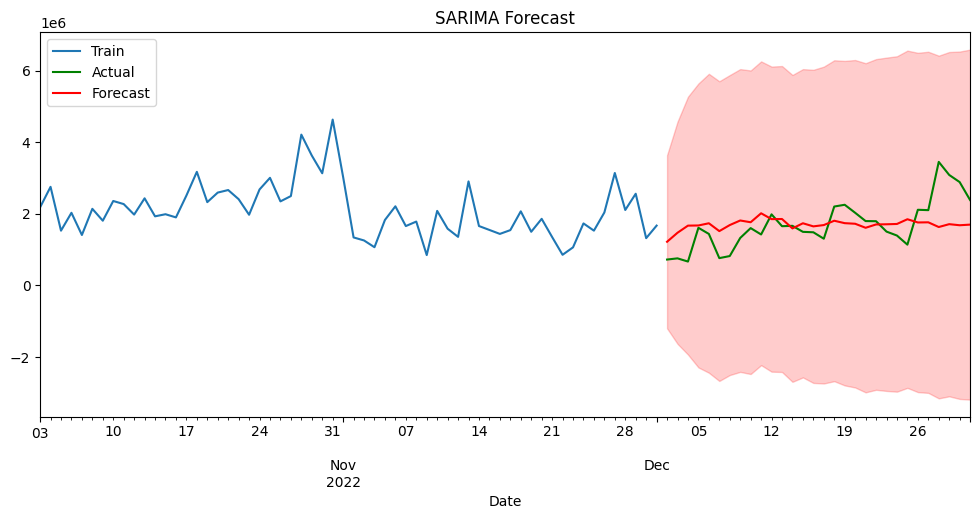

In [ ]:
forecast = result.forecast(steps=30) 
conf_int  = result.get_forecast(steps=30).conf_int()

plt.figure(figsize=(12, 5))
train[-60:].plot(label="Train")
test.plot(label="Actual", color="green")
forecast.plot(label="Forecast", color="red")
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1], alpha=0.2, color="red")
plt.legend(); plt.title("SARIMA Forecast"); plt.show()


In [ ]:
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


MAE:  505023.73
RMSE: 649741.17
MAPE: 36.17%


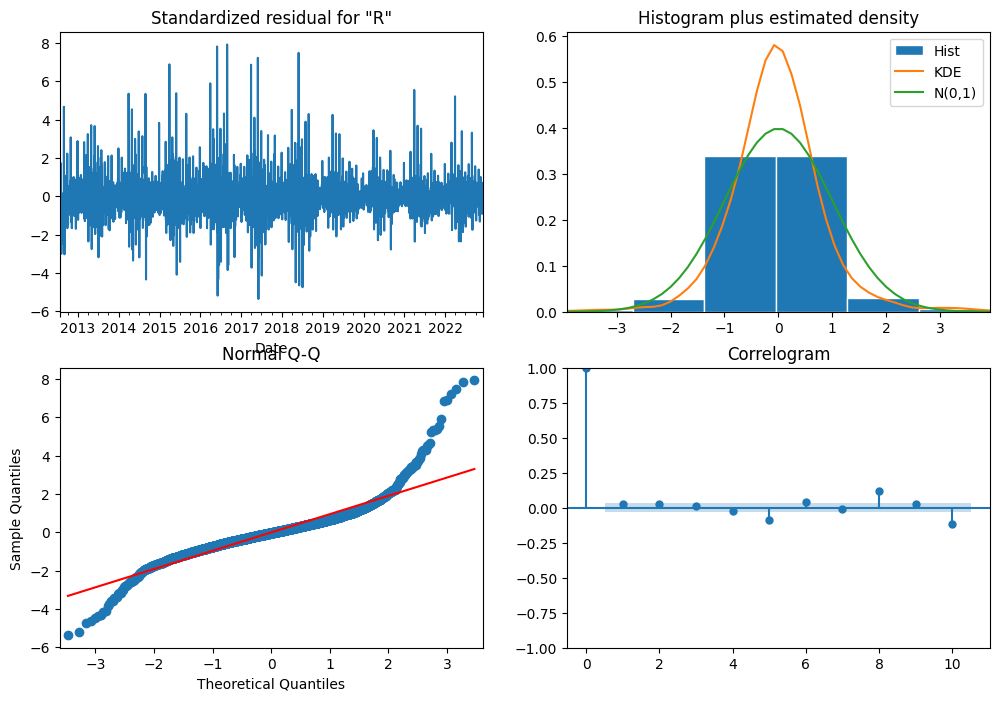

In [ ]:
result.plot_diagnostics(figsize=(12, 8))
plt.show()


In [ ]:
real_test = pd.read_csv('../../sample_submission.csv', parse_dates=['Date'], index_col='Date')


In [ ]:
forecast = result.forecast(steps=548)
real_test['Revenue'] = forecast.values
real_test


,Revenue
Date,
2023-01-01,2.510272e+06
2023-01-02,2.660409e+06
2023-01-03,2.606314e+06
2023-01-04,2.530497e+06
2023-01-05,2.583952e+06
...,...
2024-06-27,3.270121e+06
2024-06-28,3.269982e+06
2024-06-29,3.269933e+06


In [ ]:
real_test.tail()


,Revenue
Date,
2024-06-27,3.270121e+06
2024-06-28,3.269982e+06
2024-06-29,3.269933e+06
2024-06-30,3.269928e+06
2024-07-01,3.270112e+06


# COGS SARIMAX

In [ ]:
adf_test(df["COGS"])


ADF Statistic: -2.4481
p-value: 0.1286
→ Cần lấy SAI PHÂN


In [ ]:
df["COGS_diff"] = df["COGS"].diff()
adf_test(df["COGS_diff"])


ADF Statistic: -23.3294
p-value: 0.0000
→ Chuỗi DỪNG


In [ ]:
model_auto = auto_arima(
    df["COGS"],
    seasonal=True,
    m=7,                    # chu kỳ mùa vụ (7=tuần, 365=năm)
    d=None,                 # tự phát hiện d
    D=None,                 # tự phát hiện D
    information_criterion="aic",
    stepwise=True,          # nhanh hơn exhaustive search
    trace=True,             # in kết quả từng bước
    error_action="ignore",
    suppress_warnings=True,
)
print(model_auto.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=117597.007, Time=3.17 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=118087.965, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=117986.837, Time=0.20 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=118006.628, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=118085.966, Time=0.02 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=117617.990, Time=2.51 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=117893.788, Time=2.27 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=inf, Time=7.56 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=117595.061, Time=9.91 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=117989.036, Time=1.25 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=117512.230, Time=8.12 sec
 ARIMA(1,1,2)(2,0,2)[7] intercept   : AIC=117506.958, Time=8.39 sec
 ARIMA(1,1,2)(1,0,2)[7] intercept   : AIC=117919.636, Time=2.83 sec
 ARIMA(1,1,2)(2,0,1)[7] intercept   : AIC=117918.503, Time=1.87 sec
 ARIMA(1,1,2

In [ ]:
order         = model_auto.order           # (p, d, q)
seasonal_order = model_auto.seasonal_order # (P, D, Q, s)


In [ ]:
train = df["COGS"]


In [ ]:
model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False)
result = model.fit(disp=False)
print(result.summary())


                                     SARIMAX Results                                     
Dep. Variable:                              COGS   No. Observations:                 3833
Model:             SARIMAX(1, 1, 2)x(2, 0, 2, 7)   Log Likelihood              -59948.711
Date:                           Fri, 24 Apr 2026   AIC                         119913.422
Time:                                   16:42:39   BIC                         119963.396
Sample:                               07-04-2012   HQIC                        119931.179
                                    - 12-31-2022                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6143      0.109      5.633      0.000       0.401       0.828
ma.L1         -2.3313      0.100    -23.258

In [ ]:
forecast = result.forecast(steps=548)
real_test['COGS'] = forecast.values
real_test


,Revenue,COGS
Date,,
2023-01-01,2.588832e+06,2.510272e+06
2023-01-02,2.752957e+06,2.660409e+06
2023-01-03,2.689314e+06,2.606314e+06
2023-01-04,2.621070e+06,2.530497e+06
2023-01-05,2.666779e+06,2.583952e+06
...,...,...
2024-06-27,3.432649e+06,3.270121e+06
2024-06-28,3.432544e+06,3.269982e+06
2024-06-29,3.432504e+06,3.269933e+06


In [ ]:
real_test.to_csv('SARIMAX.csv')
